In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print("All libraries loaded")

All libraries loaded


In [27]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [28]:
df.shape

(6607, 20)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [30]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [31]:
df[df["Exam_Score"] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [32]:
print("DTYPES & NULL COUNTS")
print(df.info())

print("\nMISSING VALUES")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print("\nNUMERICAL SUMMARY")
df.describe()

DTYPES & NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence             

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


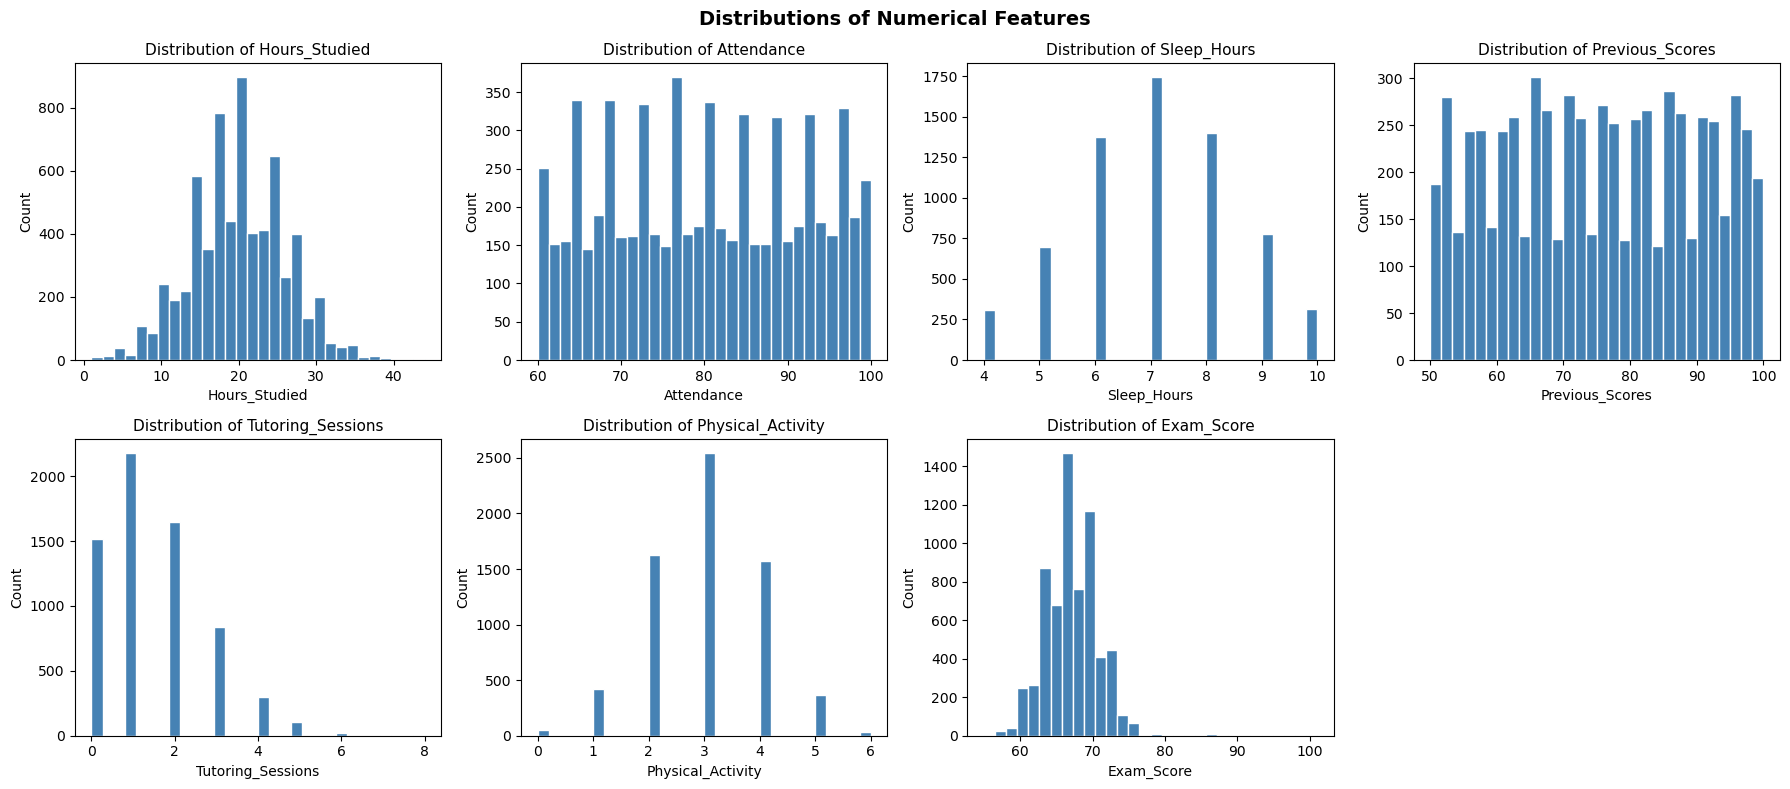

Saved


In [33]:
import os

numerical_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 
                  'Previous_Scores', 'Tutoring_Sessions', 
                  'Physical_Activity', 'Exam_Score']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)

os.makedirs('plots', exist_ok=True)
plt.suptitle('Distributions of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/01_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

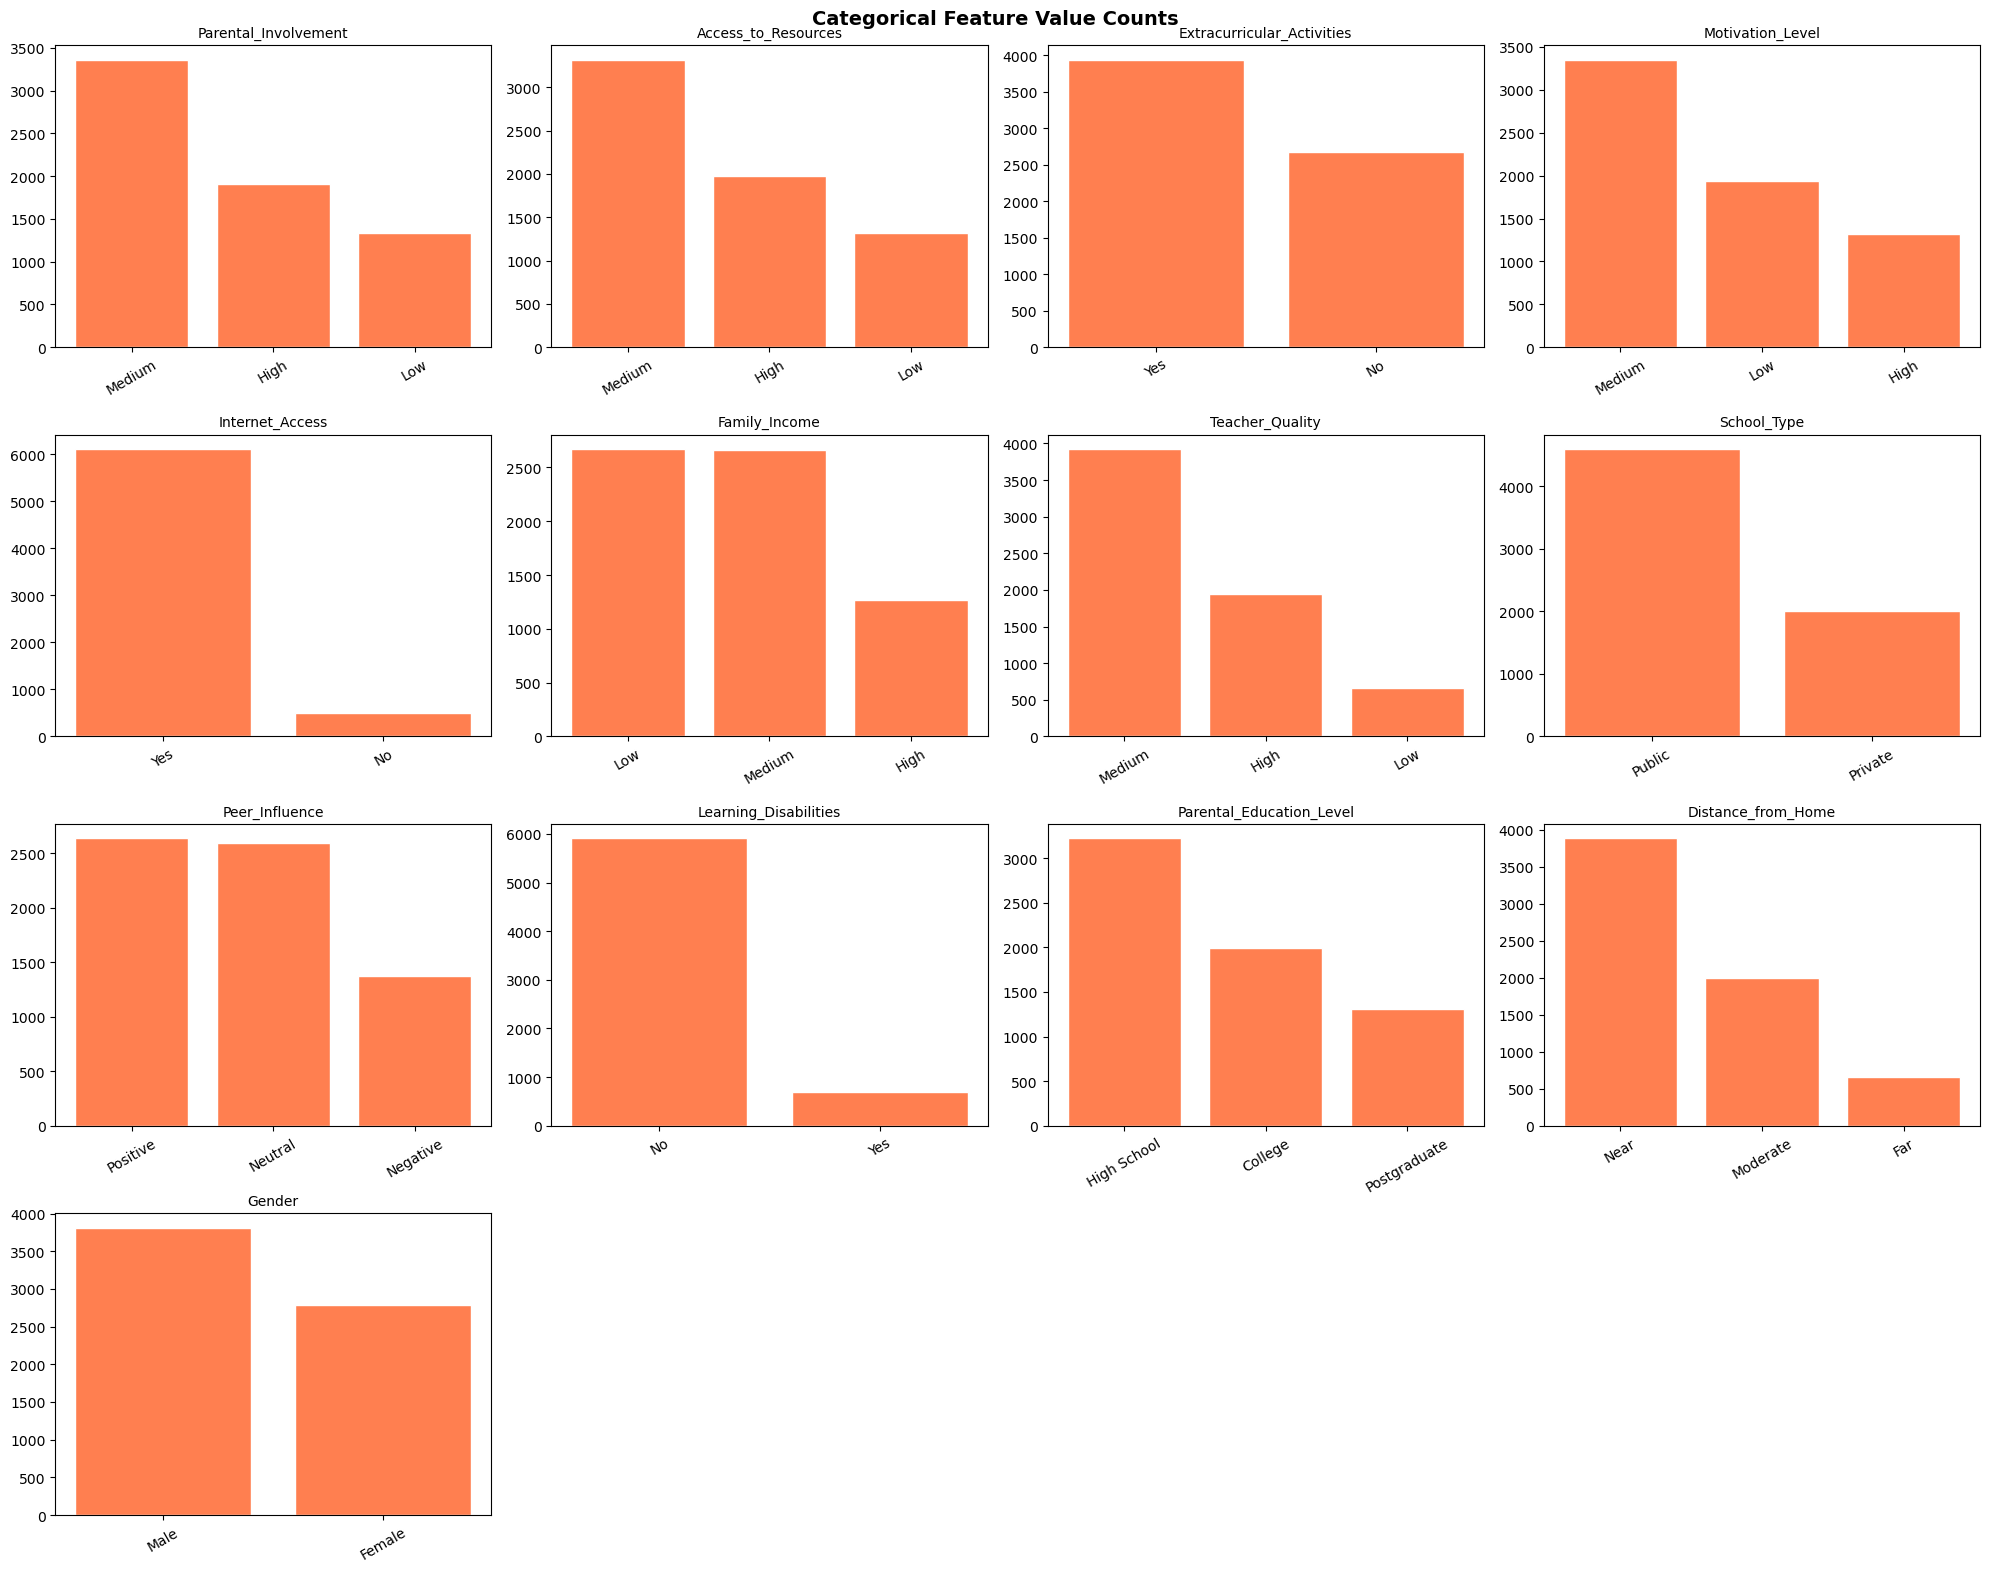

In [34]:
categorical_cols = ['Parental_Involvement', 'Access_to_Resources', 
                    'Extracurricular_Activities', 'Motivation_Level',
                    'Internet_Access', 'Family_Income', 'Teacher_Quality',
                    'School_Type', 'Peer_Influence', 'Learning_Disabilities',
                    'Parental_Education_Level', 'Distance_from_Home', 'Gender']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='coral', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Value Counts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

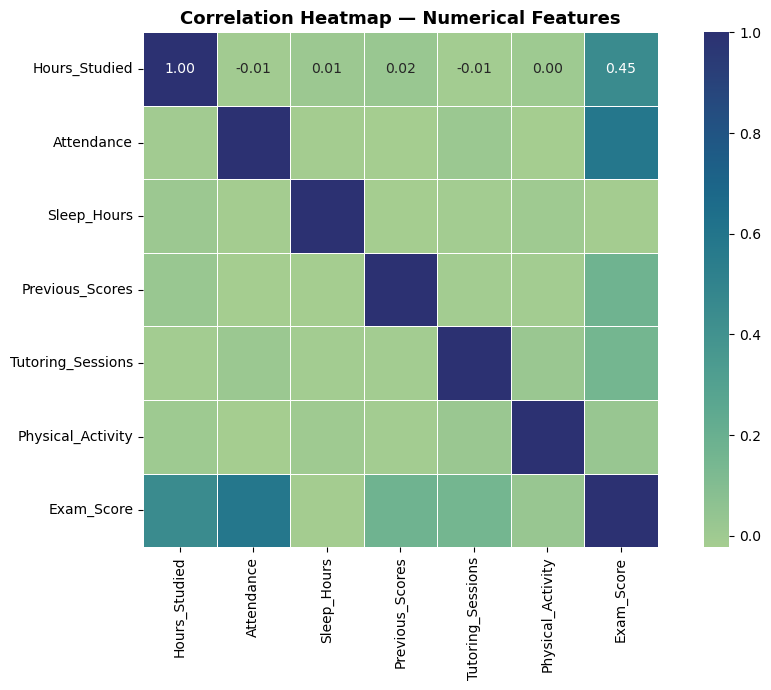

In [35]:
plt.figure(figsize=(10, 7))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='crest', 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
print(df[numerical_cols].corr()['Exam_Score'].sort_values(ascending=False).round(3))

Exam_Score           1.000
Attendance           0.581
Hours_Studied        0.445
Previous_Scores      0.175
Tutoring_Sessions    0.157
Physical_Activity    0.028
Sleep_Hours         -0.017
Name: Exam_Score, dtype: float64


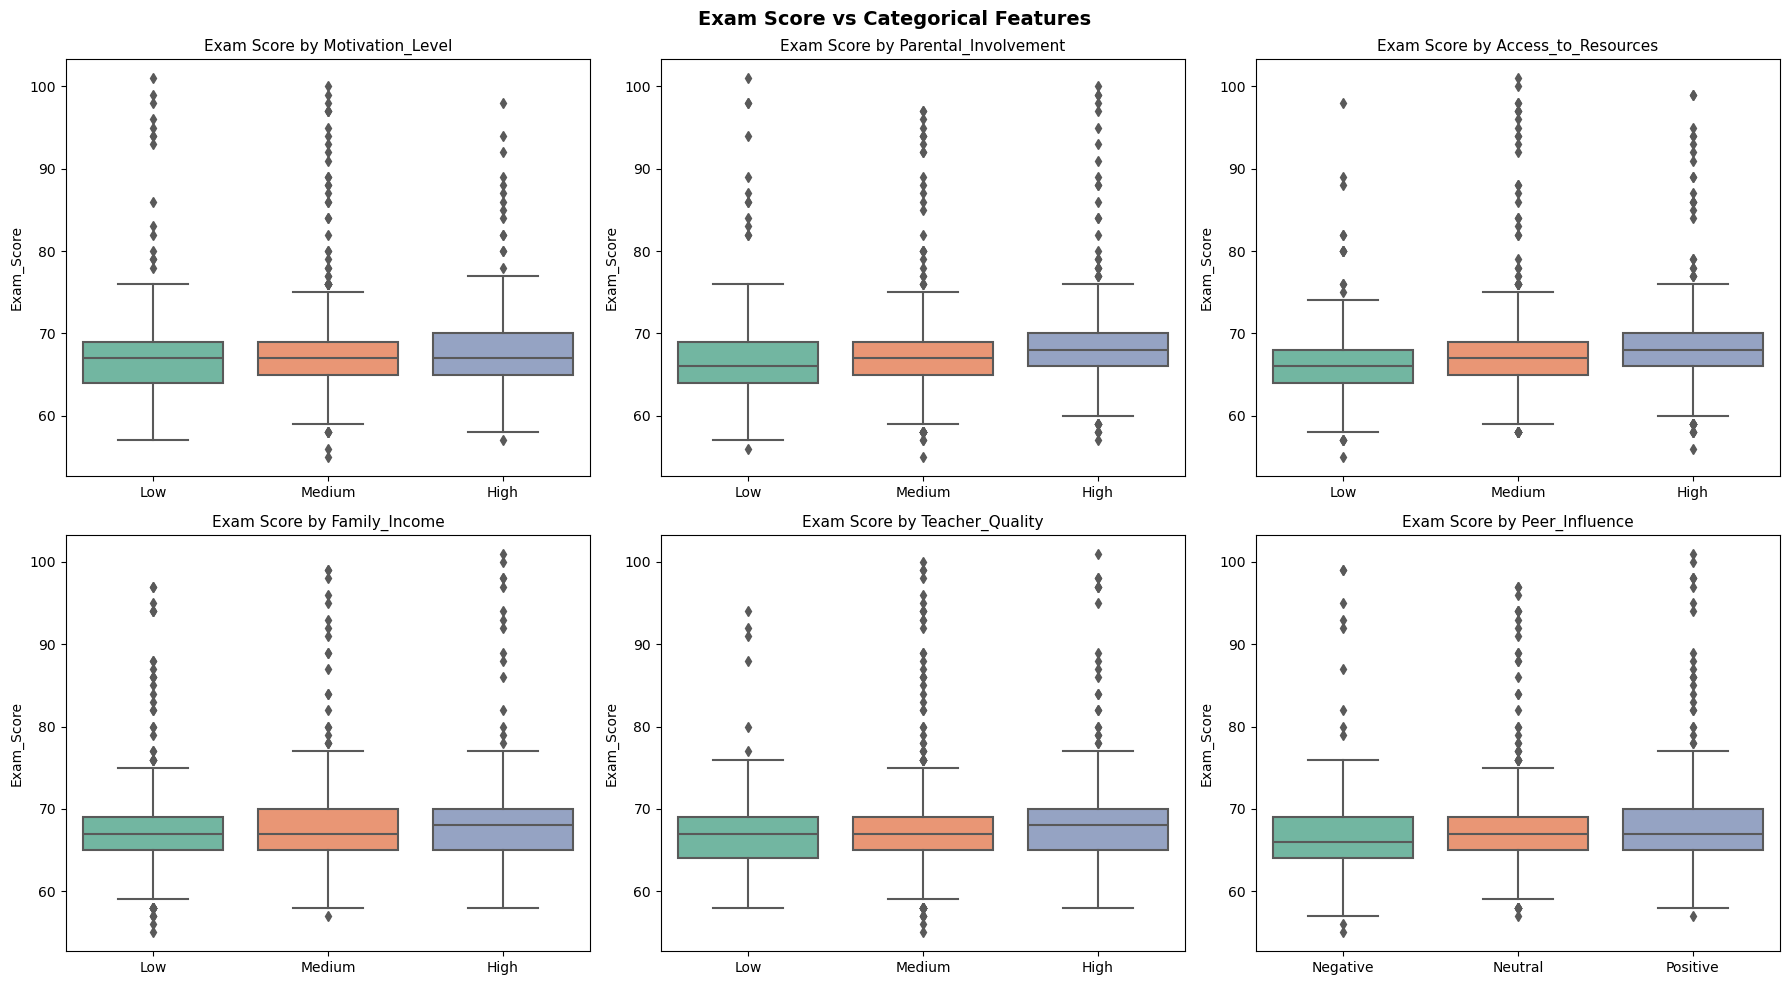

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

boxplot_pairs = [
    ('Motivation_Level', ['Low', 'Medium', 'High']),
    ('Parental_Involvement', ['Low', 'Medium', 'High']),
    ('Access_to_Resources', ['Low', 'Medium', 'High']),
    ('Family_Income', ['Low', 'Medium', 'High']),
    ('Teacher_Quality', ['Low', 'Medium', 'High']),
    ('Peer_Influence', ['Negative', 'Neutral', 'Positive']),
]

for ax, (col, order) in zip(axes.flatten(), boxplot_pairs):
    sns.boxplot(data=df, x=col, y='Exam_Score', order=order, 
                palette='Set2', ax=ax)
    ax.set_title(f'Exam Score by {col}', fontsize=11)
    ax.set_xlabel('')

plt.suptitle('Exam Score vs Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_boxplots_exam_score.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Mode imputation for the 3 categorical columns with missing values
# Justification: <2% missingness, assumed missing at random, 
# mode is appropriate for categorical/ordinal variables

cols_to_impute = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

for col in cols_to_impute:
    mode_val = df[col].mode()[0]
    missing_count = df[col].isnull().sum()
    df[col].fillna(mode_val, inplace=True)
    print(f"'{col}': {missing_count} nulls filled with mode='{mode_val}'")

print(f"\nMissing values remaining: {df.isnull().sum().sum()}")

'Teacher_Quality': 78 nulls filled with mode='Medium'
'Parental_Education_Level': 90 nulls filled with mode='High School'
'Distance_from_Home': 67 nulls filled with mode='Near'

Missing values remaining: 0


In [39]:
df_encoded = df.copy()

# --- ORDINAL ENCODING (natural order exists) ---
ordinal_mappings = {
    'Parental_Involvement':     ['Low', 'Medium', 'High'],
    'Access_to_Resources':      ['Low', 'Medium', 'High'],
    'Motivation_Level':         ['Low', 'Medium', 'High'],
    'Family_Income':            ['Low', 'Medium', 'High'],
    'Teacher_Quality':          ['Low', 'Medium', 'High'],
    'Parental_Education_Level': ['High School', 'College', 'Postgraduate'],
    'Distance_from_Home':       ['Near', 'Moderate', 'Far'],
}

for col, order in ordinal_mappings.items():
    mapping = {val: idx for idx, val in enumerate(order)}
    df_encoded[col] = df_encoded[col].map(mapping)
    print(f"Ordinal encoded '{col}': {mapping}")

# --- BINARY ENCODING ---
binary_mappings = {
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Internet_Access':            {'No': 0, 'Yes': 1},
    'Learning_Disabilities':      {'No': 0, 'Yes': 1},
    'Gender':                     {'Male': 0, 'Female': 1},
    'School_Type':                {'Public': 0, 'Private': 1},
}

for col, mapping in binary_mappings.items():
    df_encoded[col] = df_encoded[col].map(mapping)
    print(f"Binary encoded '{col}': {mapping}")

# --- ONE-HOT ENCODING (no natural order) ---
df_encoded = pd.get_dummies(df_encoded, columns=['Peer_Influence'], prefix='Peer')
print(f"\nAfter OHE, Peer_Influence columns: {[c for c in df_encoded.columns if 'Peer' in c]}")

print(f"\nEncoded shape: {df_encoded.shape}")
df_encoded.head()

Ordinal encoded 'Parental_Involvement': {'Low': 0, 'Medium': 1, 'High': 2}
Ordinal encoded 'Access_to_Resources': {'Low': 0, 'Medium': 1, 'High': 2}
Ordinal encoded 'Motivation_Level': {'Low': 0, 'Medium': 1, 'High': 2}
Ordinal encoded 'Family_Income': {'Low': 0, 'Medium': 1, 'High': 2}
Ordinal encoded 'Teacher_Quality': {'Low': 0, 'Medium': 1, 'High': 2}
Ordinal encoded 'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2}
Ordinal encoded 'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2}
Binary encoded 'Extracurricular_Activities': {'No': 0, 'Yes': 1}
Binary encoded 'Internet_Access': {'No': 0, 'Yes': 1}
Binary encoded 'Learning_Disabilities': {'No': 0, 'Yes': 1}
Binary encoded 'Gender': {'Male': 0, 'Female': 1}
Binary encoded 'School_Type': {'Public': 0, 'Private': 1}

After OHE, Peer_Influence columns: ['Peer_Negative', 'Peer_Neutral', 'Peer_Positive']

Encoded shape: (6607, 22)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Peer_Negative,Peer_Neutral,Peer_Positive
0,23,84,0,2,0,7,73,0,1,0,0,1,0,3,0,0,0,0,67,0,0,1
1,19,64,0,1,0,8,59,0,1,2,1,1,0,4,0,1,1,1,61,1,0,0
2,24,98,1,1,1,7,91,1,1,2,1,1,0,4,0,2,0,0,74,0,1,0
3,29,89,0,1,1,8,98,1,1,1,1,1,0,4,0,0,1,0,71,1,0,0
4,19,92,1,1,1,6,65,1,1,3,1,2,0,4,0,1,0,1,70,0,1,0


In [40]:

X = df_encoded.drop(columns=['Exam_Score'])
exam_scores = df_encoded['Exam_Score'].copy()  # save for later profiling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Scaling complete. Feature matrix shape: {X_scaled_df.shape}")
print(f"\nMean (should be ~0):\n{X_scaled_df.mean().round(3)}")
print(f"\nStd (should be ~1):\n{X_scaled_df.std().round(3)}")

Scaling complete. Feature matrix shape: (6607, 21)

Mean (should be ~0):
Hours_Studied                -0.0
Attendance                   -0.0
Parental_Involvement         -0.0
Access_to_Resources           0.0
Extracurricular_Activities    0.0
Sleep_Hours                  -0.0
Previous_Scores               0.0
Motivation_Level              0.0
Internet_Access              -0.0
Tutoring_Sessions             0.0
Family_Income                -0.0
Teacher_Quality               0.0
School_Type                   0.0
Physical_Activity            -0.0
Learning_Disabilities        -0.0
Parental_Education_Level     -0.0
Distance_from_Home           -0.0
Gender                        0.0
Peer_Negative                 0.0
Peer_Neutral                  0.0
Peer_Positive                -0.0
dtype: float64

Std (should be ~1):
Hours_Studied                 1.0
Attendance                    1.0
Parental_Involvement          1.0
Access_to_Resources           1.0
Extracurricular_Activities    1.0
Sleep_H

In [41]:
# PCA FOR VISUALISATION
# Issue: Full feature matrix includes binary and low-cardinality 
# ordinal features which dilute explained variance in pca
# so pca visualisation uses continuous features only
# clustering still uses full X_scaled all 21 features

# Define continuous/numerical features for PCA visualisation
continuous_cols = [
    'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
    'Tutoring_Sessions', 'Physical_Activity'
]
# Exam_Score excluded

X_continuous = X_scaled_df[continuous_cols].values

# 2D PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_continuous)

# 3D PCA
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_continuous)

print(f"2D PCA explained variance: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")
print(f"3D PCA explained variance: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\nNote: PCA applied to {len(continuous_cols)} continuous features only")
print(f"Clustering uses full feature matrix ({X_scaled_df.shape[1]} features)")

2D PCA explained variance: 34.62%
3D PCA explained variance: 51.57%

Note: PCA applied to 6 continuous features only
Clustering uses full feature matrix (21 features)


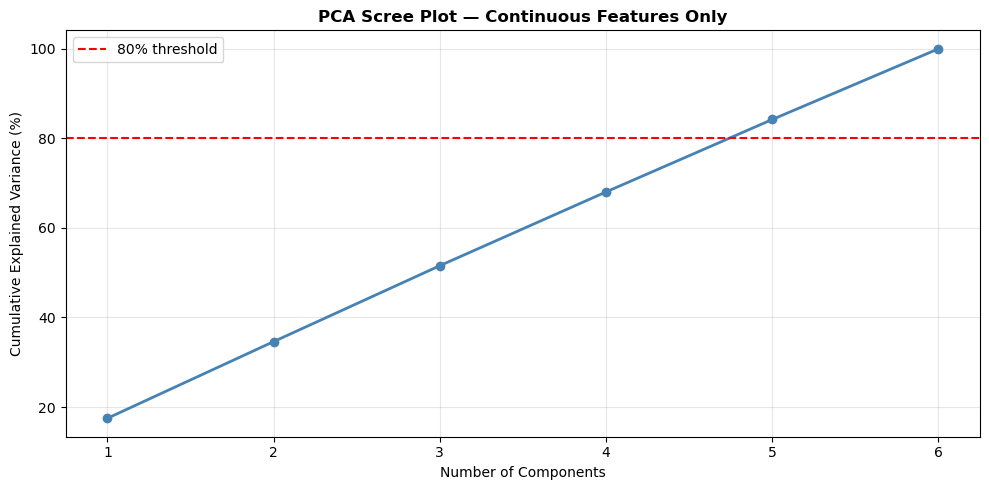

In [42]:
pca_full = PCA(random_state=42)
pca_full.fit(X_continuous)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', 
         color='steelblue', linewidth=2)
plt.axhline(y=80, color='red', linestyle='--', label='80% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Scree Plot — Continuous Features Only', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/05_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# overwrite
pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2']).to_csv('data/X_pca_2d.csv', index=False)
pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3']).to_csv('data/X_pca_3d.csv', index=False)
print("Updated PCA files saved ✓")
print("Teammates can reload data/X_pca_2d.csv for cleaner cluster visualisations")

Updated PCA files saved ✓
Teammates can reload data/X_pca_2d.csv for cleaner cluster visualisations


In [44]:
import os
os.makedirs('plots', exist_ok=True)
os.makedirs('data', exist_ok=True)

# Save everything
X_scaled_df.to_csv('data/X_scaled.csv', index=False)
pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2']).to_csv('data/X_pca_2d.csv', index=False)
pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3']).to_csv('data/X_pca_3d.csv', index=False)
exam_scores.to_csv('data/exam_scores.csv', index=False)
df_encoded.to_csv('data/student_preprocessed.csv', index=False)

print("Saved:")
print("  data/X_scaled.csv          < main clustering input")
print("  data/X_pca_2d.csv          < for 2D scatter plots")
print("  data/X_pca_3d.csv          < for 3D scatter plots")
print("  data/exam_scores.csv       < for post-cluster profiling")
print("  data/student_preprocessed.csv < full encoded dataset")
print("\nPreprocessing complete")

Saved:
  data/X_scaled.csv          < main clustering input
  data/X_pca_2d.csv          < for 2D scatter plots
  data/X_pca_3d.csv          < for 3D scatter plots
  data/exam_scores.csv       < for post-cluster profiling
  data/student_preprocessed.csv < full encoded dataset

Preprocessing complete


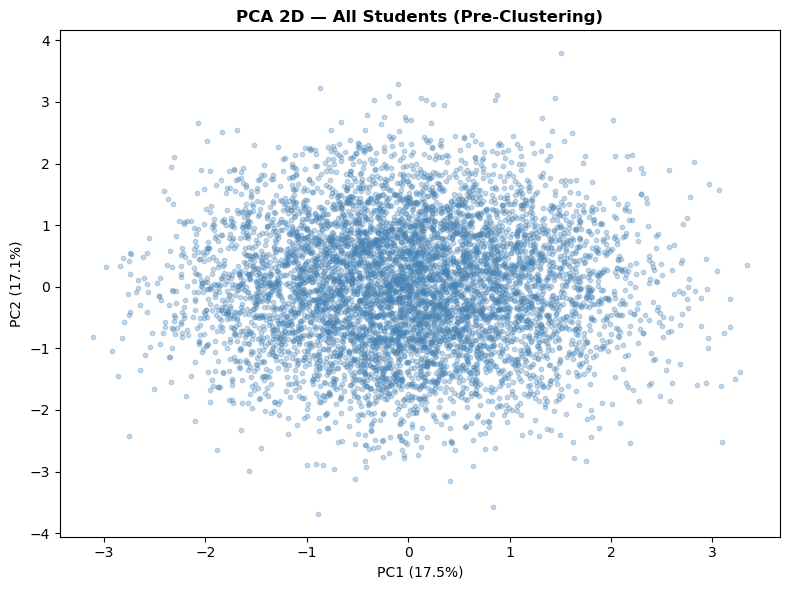

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.3, s=10, color='steelblue')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA 2D — All Students (Pre-Clustering)', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_pca_scatter_preclustering.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


=== IMPUTATION STRATEGY COMPARISON ===
Original shape:        (6607, 20)
Mode imputation shape: (6607, 20)  (0 rows lost)
Row deletion shape:    (6378, 20)  (229 rows lost)



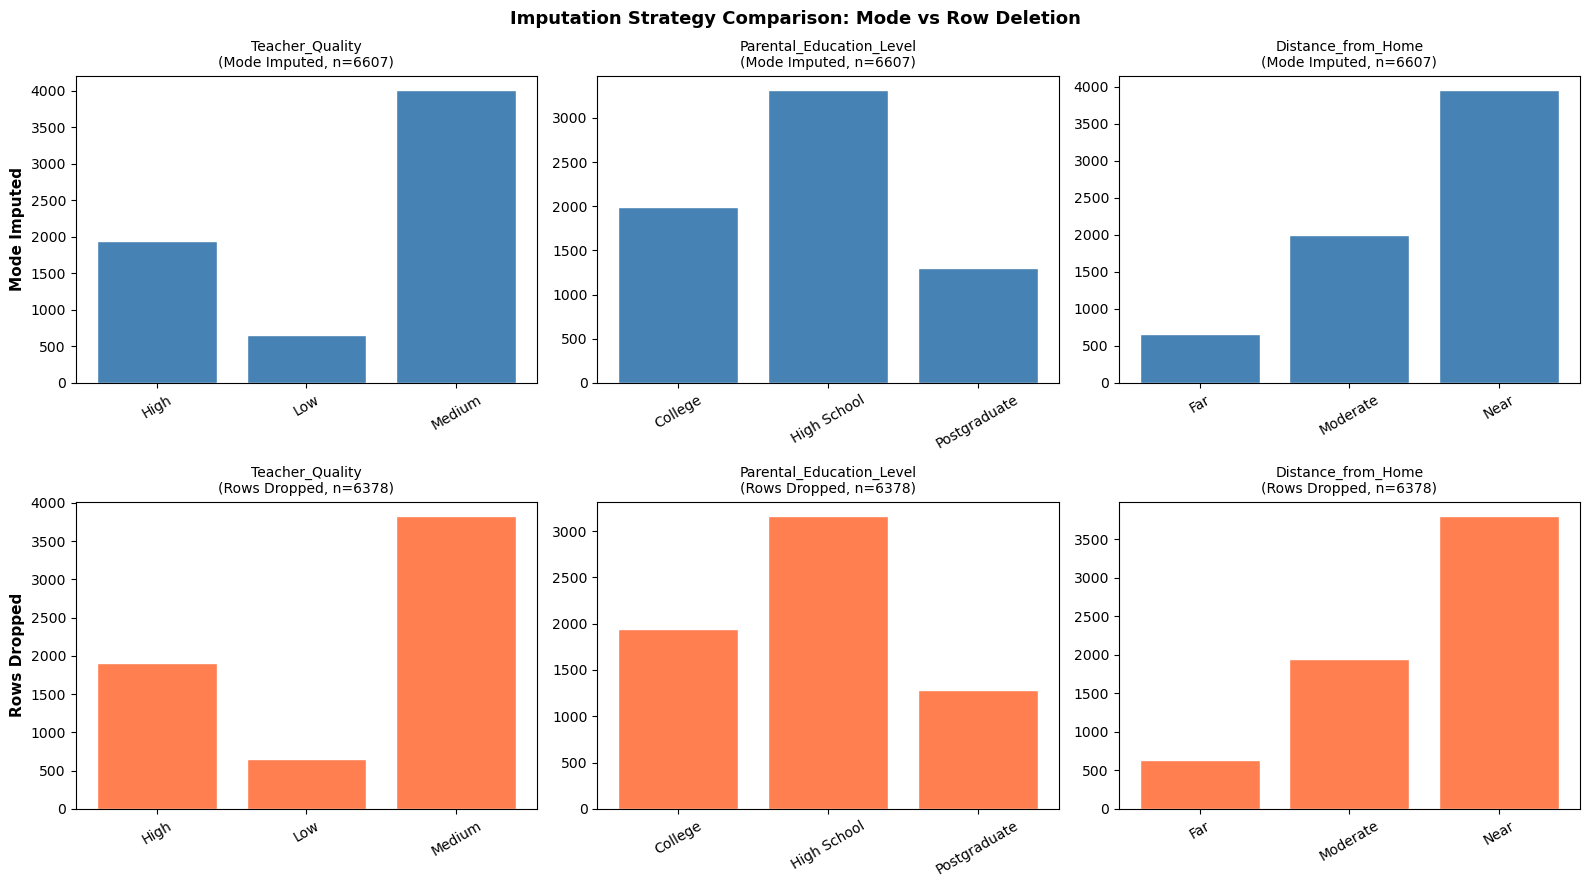

CONCLUSION
Distributions are near-identical between both strategies.
Mode imputation selected: retains all 6,607 rows, negligible bias at <2% missingness.


In [47]:
# IMPUTATION COMPARISON: Mode vs Row Deletion

df_original = pd.read_csv('StudentPerformanceFactors.csv')
cols_with_missing = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

# Mode imputation (what we already used)
df_mode_compare = df_original.copy()
for col in cols_with_missing:
    mode_val = df_mode_compare[col].mode()[0]
    df_mode_compare[col].fillna(mode_val, inplace=True)

# Or Drop rows with missing values
df_dropped_compare = df_original.dropna(subset=cols_with_missing).reset_index(drop=True)

print("=== IMPUTATION STRATEGY COMPARISON ===")
print(f"Original shape:        {df_original.shape}")
print(f"Mode imputation shape: {df_mode_compare.shape}  (0 rows lost)")
print(f"Row deletion shape:    {df_dropped_compare.shape}  ({len(df_original) - len(df_dropped_compare)} rows lost)\n")

# Compare distributions of the 3 affected columns
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(cols_with_missing):
    # Mode imputed (top row)
    vc_mode = df_mode_compare[col].value_counts().sort_index()
    axes[0, i].bar(vc_mode.index, vc_mode.values, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col}\n(Mode Imputed, n={len(df_mode_compare)})', fontsize=10)
    axes[0, i].tick_params(axis='x', rotation=30)

    # Row dropped (bottom row)
    vc_drop = df_dropped_compare[col].value_counts().sort_index()
    axes[1, i].bar(vc_drop.index, vc_drop.values, color='coral', edgecolor='white')
    axes[1, i].set_title(f'{col}\n(Rows Dropped, n={len(df_dropped_compare)})', fontsize=10)
    axes[1, i].tick_params(axis='x', rotation=30)

axes[0, 0].set_ylabel('Mode Imputed', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Rows Dropped', fontsize=11, fontweight='bold')

plt.suptitle('Imputation Strategy Comparison: Mode vs Row Deletion',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/imputation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("CONCLUSION")
print("Distributions are near-identical between both strategies.")
print("Mode imputation selected: retains all 6,607 rows, negligible bias at <2% missingness.")

In [48]:
# Check which features dominate PC1 and PC2
pca_2d_full = PCA(n_components=2, random_state=42)
pca_2d_full.fit(X_scaled)

loadings = pd.DataFrame(
    pca_2d_full.components_.T,
    index=X_scaled_df.columns,
    columns=['PC1', 'PC2']
)

print("TOP FEATURES DRIVING PC1")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print("\nTOP FEATURES DRIVING PC2")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

TOP FEATURES DRIVING PC1
Peer_Positive                 0.705217
Peer_Neutral                  0.699187
Extracurricular_Activities    0.055024
Attendance                    0.046088
Previous_Scores               0.042548
Name: PC1, dtype: float64

TOP FEATURES DRIVING PC2
Peer_Negative           0.851958
Peer_Neutral            0.361384
Peer_Positive           0.346286
Parental_Involvement    0.082750
Family_Income           0.068963
Name: PC2, dtype: float64


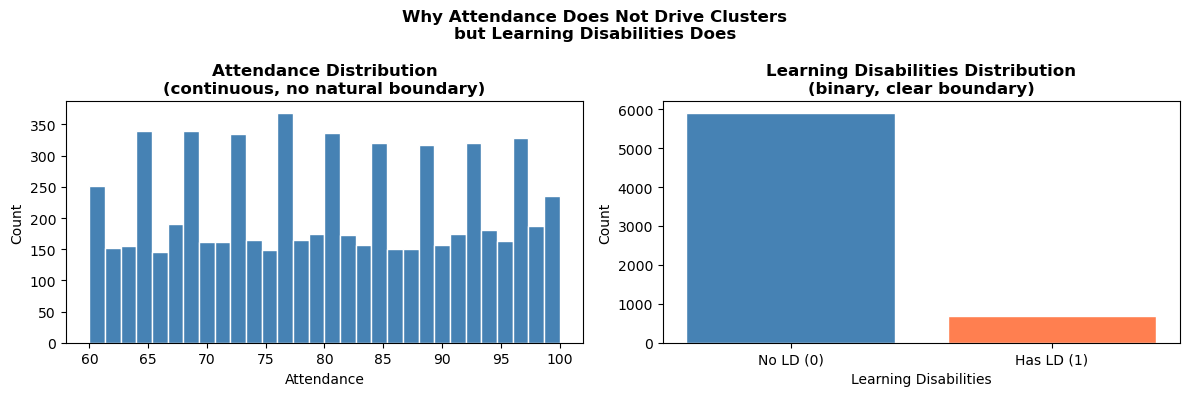

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Attendance distribution shows continuous and no natural gap
axes[0].hist(df['Attendance'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Attendance Distribution\n(continuous, no natural boundary)', 
                   fontweight='bold')
axes[0].set_xlabel('Attendance')
axes[0].set_ylabel('Count')

# Learning_Disabilities distribution -shows binary
axes[1].bar(['No LD (0)', 'Has LD (1)'], 
             df['Learning_Disabilities'].map({'No': 0, 'Yes': 1}).value_counts().sort_index().values,
             color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('Learning Disabilities Distribution\n(binary, clear boundary)', 
                   fontweight='bold')
axes[1].set_xlabel('Learning Disabilities')
axes[1].set_ylabel('Count')

plt.suptitle('Why Attendance Does Not Drive Clusters\nbut Learning Disabilities Does', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/attendance_vs_ld_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
import pickle

# reload raw data and redo encoding from scratch to get unscaled values
df_raw = pd.read_csv('StudentPerformanceFactors.csv')

# impute
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    df_raw[col].fillna(df_raw[col].mode()[0], inplace=True)

# encode exactly as before
ordinal_mappings = {
    'Parental_Involvement': ['Low','Medium','High'],
    'Access_to_Resources': ['Low','Medium','High'],
    'Motivation_Level': ['Low','Medium','High'],
    'Family_Income': ['Low','Medium','High'],
    'Teacher_Quality': ['Low','Medium','High'],
    'Parental_Education_Level': ['High School','College','Postgraduate'],
    'Distance_from_Home': ['Near','Moderate','Far'],
}
for col, order in ordinal_mappings.items():
    mapping = {val: idx for idx, val in enumerate(order)}
    df_raw[col] = df_raw[col].map(mapping)

binary_mappings = {
    'Extracurricular_Activities': {'No':0,'Yes':1},
    'Internet_Access': {'No':0,'Yes':1},
    'Learning_Disabilities': {'No':0,'Yes':1},
    'Gender': {'Male':0,'Female':1},
    'School_Type': {'Public':0,'Private':1},
}
for col, mapping in binary_mappings.items():
    df_raw[col] = df_raw[col].map(mapping)

df_raw = pd.get_dummies(df_raw, columns=['Peer_Influence'], prefix='Peer')

X_unscaled = df_raw.drop(columns=['Exam_Score'])

scaler_to_save = StandardScaler()
scaler_to_save.fit(X_unscaled)

# verify
test = scaler_to_save.transform(X_unscaled.iloc[:5])
print(f"Mean of first row: {test[0].mean():.4f} (should be ~0)")
print(f"Std of first row: {test[0].std():.4f} (should be ~1)")

with open('data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler_to_save, f)

print("Scaler saved")

Mean of first row: -0.3799 (should be ~0)
Std of first row: 0.7711 (should be ~1)
Scaler saved
